<img src="Maintenance_Engineering.jpeg">

# Optimizing Industrial Operations Through Predictive Maintenance Modeling
---
**Author:** Reeves Gonah  
**Date:** 5/5/2026  
**Project:** Phase 3 Project  
**Data Source:** [AI4I 2020 Predictive Maintenance Dataset](https://www.kaggle.com/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020)  



---
## <u>Introduction</u>
A mid-sized (fictional) manufacturing firm, *Apex Precision Components Ltd.*, has recently completed its annual operational review and identified a consistent rise in maintenance costs and unplanned machine downtime across its production lines. The company specializes in producing high-tolerance mechanical components—such as shafts and gears, using CNC and automated machining systems similar to those represented in the AI4I 2020 Predictive Maintenance Dataset. These disruptions have led to delayed orders, increased repair expenses, and reduced overall efficiency. To address this, the company is exploring data-driven approaches to better understand the conditions under which machine failures occur, with the aim of proactively identifying high-risk operating states and optimizing maintenance decisions.

---
## <u>Business Understanding</u>

### **Business Context**   
   Unplanned machine downtime is one of the most expensive operational challenges in manufacturing. When a critical machine fails unexpectedly, production lines stop, delivery deadlines are missed, and emergency repairs can cost significantly more than planned maintenance.

### **Business Problem**  
   The company currently relies on reactive or rigid scheduled maintenance. It is investigating use of a data-driven approach to identify high-risk operating conditions and predict failures early, enabling proactive intervention and reducing downtime.

### **Business Objectives**  
   Develop a binary classification model that predicts machine failure risk from sensor readings (e.g., temperature, rotational speed & tool wear). These predictions will inform maintenance decisions by triggering inspections only when risk is elevated, reducing unplanned stoppages and repair costs.

### **Business Questions**  
*   Which sensor conditions or combinations most strongly indicate an impending machine failure?
*   Can a machine learning model distinguish between normal and failure-prone states with sufficient accuracy to be operationally trusted?
*   What is the right balance between catching all failures and controlling false alarms?

### **Potential Beneficiaries**  
*   Maintenance teams, plant managers, and production planners benefit from early warnings that enable proactive repairs
*   Reliability engineers gain insight into failure drivers to improve operating policies
*   Finance teams benefit from reduced emergency repair costs and more predictable maintenance budgets

### **Success Criteria**
   Because missed failures (false negatives) are more costly than unnecessary inspections (false positives), recall is prioritized. The model should capture a high proportion of failure cases (target ≥ 70–75%), while maintaining precision above ~60% to ensure alerts remain actionable. The F1-score will be used for overall model comparison.

### **Technical Approach**  
The relationships between sensor readings and machine failure are influenced by multiple interacting factors, such as temperature, torque, rotational speed, and tool wear. These relationships are unlikely to be captured effectively through simple rule-based thresholds or basic analysis. As such, a machine learning approach is appropriate to model these complex patterns and provide more reliable failure predictions.

---

## <u>Data Understanding</u>

### **Data Source and Description**

A data first approach was used, and the dataset selected was the AI4I 2020 Predictive Maintenance Dataset published on [kaggle](https://www.kaggle.com/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020)  by Stephan Matzka, last updated in 2023. Description attached indicates that it contains 10,000 synthetic observations of a milling machine’s sensor readings (air and process temperature, rotational speed, torque, tool wear) and product type, with a binary 'machine_failure' target. 

The dataset is highly appropriate because it reflects realistic industrial signals, includes a naturally low failure rate, and provides sufficient data volume and feature variety to train, compare, and interpret classification models for predictive maintenance.

### **Data Load and Initial Exploration**

In [27]:
# Importing the necessary libraries for this project
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [3]:
#Load the Data into a pandas dataframe
data = pd.read_csv("ai4i2020.csv")

#display the first 5 rows of the dataframe and the size
print(data.shape)
data.head()


(10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


The author indicates that the last 5 unlabeled columns are indicative of the five independent failure modes:
*       TWF - Tool Wear Failure
*       HDF - Heat Dissipation Failure
*       PWF - Power Failure
*       OSF - Overstrain Failure
*       RNF - Random Failure  

These are just types of failures and not features. Additional information about them and how they occur is in the kaggle description

Looking at the null values and datatypes:

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

### **Overview**  
The dataset contains 10,000 rows and 14 total columns, 6 of which are not of use (1 index), leaving 8 usable columns.  
No row contains null values, however 2 columns are of string format which will need addressing.

### **Feature and Variable Distributions**

Taking a look at some of the preliminary statistics, relationships and distributions:

In [5]:
# Column decriptive statistics
data.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [6]:
# Inspecting the class balance of the target variable
print(data['Machine failure'].value_counts())
print('\n')
print(data['Machine failure'].value_counts(normalize=True))

0    9661
1     339
Name: Machine failure, dtype: int64


0    0.9661
1    0.0339
Name: Machine failure, dtype: float64


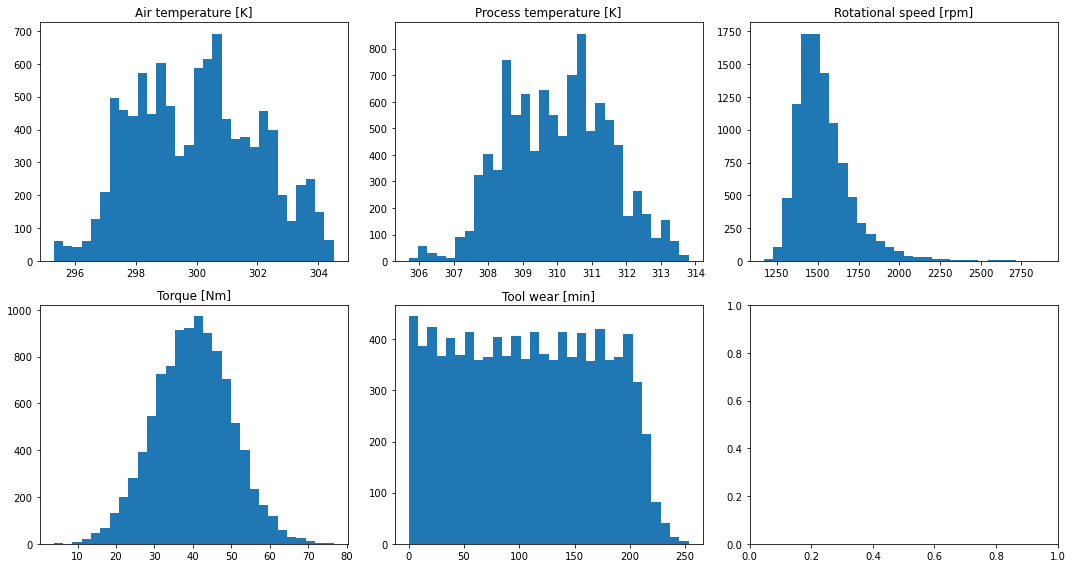

In [7]:
# Visually inspect the numeric features for distribution
#Plot on one figure to reduce redundancy

# Select relevant numeric features
features = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

# Plot histograms
for i, col in enumerate(features):
    axes[i].hist(data[col], bins=30)
    axes[i].set_title(col)


plt.tight_layout()
plt.show()

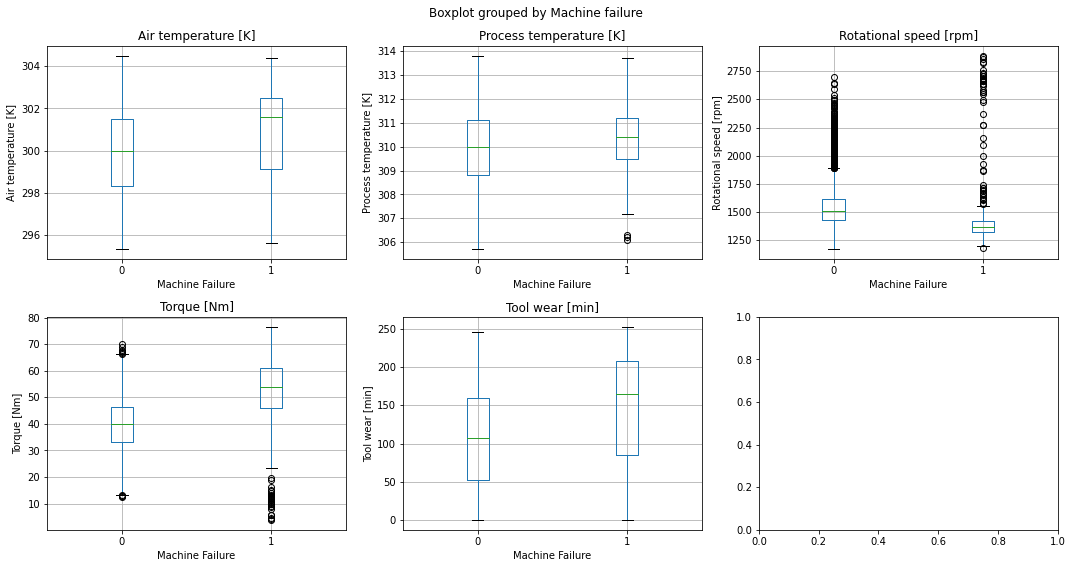

In [8]:
# Creating the figure and axes as previously done
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    #using the inbuilt pandas boxplots for ease
    data.boxplot(column=col, by='Machine failure', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('Machine Failure')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

In [9]:
# A few features seem like they would be correlated
# (Air temp and process temp) and (torque and rotational speed)
# isolating these features
corr_features = ['Air temperature [K]','Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]']

# Getting the correlation matrix
corr_matrix = data[corr_features].corr()
print(corr_matrix)

                         Air temperature [K]  Process temperature [K]  \
Air temperature [K]                 1.000000                 0.876107   
Process temperature [K]             0.876107                 1.000000   
Rotational speed [rpm]              0.022670                 0.019277   
Torque [Nm]                        -0.013778                -0.014061   

                         Rotational speed [rpm]  Torque [Nm]  
Air temperature [K]                    0.022670    -0.013778  
Process temperature [K]                0.019277    -0.014061  
Rotational speed [rpm]                 1.000000    -0.875027  
Torque [Nm]                           -0.875027     1.000000  


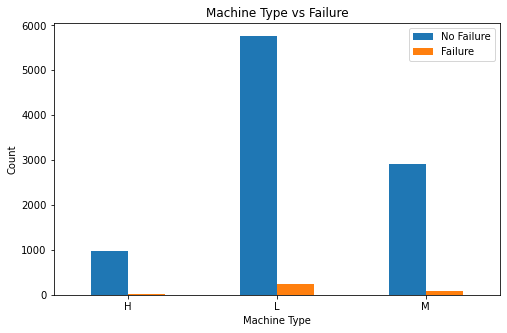

In [10]:
# Lastly Investigating the categorical column distribution and relationship to the target variable

# Create grouped counts
grouped = data.groupby(['Type', 'Machine failure']).size().unstack()

# Plot
grouped.plot(kind='bar', figsize=(8, 5))

plt.title('Machine Type vs Failure')
plt.xlabel('Machine Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(['No Failure', 'Failure'])

plt.show()

**Observations, Patterns and Insight**
1. There is class imbalance in the target variable. Failures are much fewer than non failures therefore a technique such as resampling might be necessary to avoid creating a biased model.  
2. The feature distributions show that most variables are reasonably continuous, though some exhibit skewness and outliers (e.g., rotational speed and torque).
3. Machines that experienced failure tend to operate at higher torque levels and exhibit greater tool wear, indicating that mechanical stress and accumulated wear are strong indicators of failure risk.
4. The distribution of failures across machine types shows that certain machine categories (L) experience higher failure rates than others though this may be because they have the largeset smount of machines.
5. Torque and tool wear show stronger positive correlations with machine failure, reinforcing their importance as predictors. Additionally, air and process temperatures are highly correlated with each other, indicating potential redundancy.
---

## <u>Data Preparation and Preprocessing</u>

### **Data Cleaning**

In [11]:
# No missing values
# Drop Unnecessary columns
data.drop(columns=['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'], axis=1, inplace=True)

# Clean and standardize volumn names
column_names = ['Machine_Type', 'Air_Temp', 'Process_Temp', 'Rot_Speed', 'Torque', 'Tool_Wear', 'Machine_Failure']

#Assign new Column names
data.columns = column_names

### **Feature Engineering**

In [12]:
# Create new features/ Calculated columns
# This can be done before the testing and training data is split as they do not rely on dataset statistics

data["Temp_Difference"] = data['Process_Temp'] - data['Air_Temp']
data["Mechanical_Power"] = data['Torque'] * data['Rot_Speed']

**Justification for Engineered Features (based on domain knowledge):**

*Temperature difference:* This captures the heat buildup in the machine relative to ambient conditions, which may signal excessive friction, inadequate cooling, or impending bearing failure more directly than either temperature alone.

*Mechanical power:* Power is a fundamental physical quantity representing the rate of work being done. Abnormally high power can indicate overloaded cutting conditions, while abnormally low power at a given speed might suggest tool disengagement or slipping. Both patterns are mechanically meaningful for predicting failures.

### **Splitting the training and testing data**

To prevent data leakage, splitting of the dataset is done here.
A standard train_test_split is be done using scikitlearns model selection library. A 70/30 split will be done to ensure a decent amount of testing data to reach a meaningful conclusion

In [13]:
# Declare the feature and target variables
X = data.drop(columns='Machine_Failure', axis=1)
y = data['Machine_Failure']

In [14]:
# Using a test size of 0.3 as mentioned earlier, and a random state of 73 throughout
random_state = 73

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=random_state)

In [15]:
# Inspect the class distribution of the train and test target variables
print("Training set: \n", y_train.value_counts(normalize=True))
print('\n')
print("Testing set: \n", y_test.value_counts(normalize=True))

Training set: 
 0    0.965714
1    0.034286
Name: Machine_Failure, dtype: float64


Testing set: 
 0    0.967
1    0.033
Name: Machine_Failure, dtype: float64


The class distribution remains relatively conisistent across the training and testing sets.

### **Encoding Categorical Columns**

In [16]:
# The Machine_Type column is categorical and needs to be converted into numerical for machine learning
# The get dummies function from the pandas library

#create a function that will be used to one hot encode the test and training set seperately
def onehotencode(dataset):
    data_encoded = pd.get_dummies(dataset, columns=['Machine_Type'], drop_first=True, dtype=int)
    return data_encoded

# One hot encode the training set
X_train_encoded = onehotencode(X_train)

# One hot encode the test set
X_test_encoded = onehotencode(X_test)


### **Feature Scaling**  
The data needs to be scaled as numerical columns are not in the same units or ranges and would therefore be weighted differently, skewing feature importance and giving an incorrect model.  
This is particularly important for logistic regression which relies on gradient descent.  

In [17]:
# The standard scaler class from scikit learn's library will be used
# Fitting is only done on the training dataset and not the testing dataset to prevent data leakage
# Initialize the scaler
scaler = StandardScaler()

#Fit and transform the training data
X_train_scaled = scaler.fit_transform(X_train_encoded)

# Transorm the testing data using the model fitted on the training data
X_test_scaled = scaler.transform(X_test_encoded)

### **Class Balancing**  
As previously mentioned, there are very few rows containing failures as compared to those where no failure occurs, reflecting real world circumstances.  
To avoid having the model predict no failure most of the time and therefore be right majority of the time, the classes should be weighted.  
This will be done using the resampling technique

In [18]:
# The smote package from imblearn's package will be used
# instansiate
smote = SMOTE(random_state=random_state)

#fit and transform the training datasets
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

#check the results
print((y_train_resampled).value_counts())

1    6760
0    6760
Name: Machine_Failure, dtype: int64


The data is now set for modelling. It would however be useful to standardize the names of the datasets

In [19]:
#Renaming the set names for ease
#Training set
X_train_clean = X_train_resampled
y_train_clean = y_train_resampled

#Testing set
X_test_clean = X_test_scaled
y_test_clean = y_test

## <u>Modeling</u>

With clean data, a predictive model can now be trained. A supervised classification approach is adopted using both Logistic Regression and Decision Tree.  
Logistic Regression is selected as a baseline model due to its simplicity and interpretability in modeling linear relationships between sensor variables and failure probability.
The Decision Tree model to capture potential non-linear interactions that are characteristic of mechanical systems, such as stress limits and wear accumulation. 

This dual-model approach allows comparative evaluation to determine which method more effectively identifies failure-prone operating conditions, while maintaining a balance between predictive performance and interpretability.

**Baseline Logistic Regression Model**  
Because the data is already centered, the intercept is set to false, a large C to for little to no regularization, and using a MLE to get the best fit line;

In [23]:
# Using scikit-learn's Logistic Regression class
# Instantiating the class 
logreg = LogisticRegression(fit_intercept=False, C=1e12, solver='liblinear')

#Fitting the model
baseline_logreg = logreg.fit(X_train_clean, y_train_clean)

#Predicting on unseen data
y_hat_baseline_logreg = logreg.predict(X_test_clean)

**Baseline Decision Tree Classifier**  
For this, the only hyperparameter specified was the criterion. Information gain is calculated through entropy.

In [24]:
#using Scikit-learn's Decision Tree Classifier
# Instantiating 
clf = DecisionTreeClassifier(criterion='entropy')

#Training the model
baseline_clf = clf.fit(X_train_clean, y_train_clean)

#Generating predictions
y_hat_baseline_clf = clf.predict(X_test_clean)

## <u>Model Evaluation</u>

To evaluate the model, evaluation metrics such as precision, recall, accuracy and f1 score will be compared for each, and interpreted.

**Baseline Logistic Regression Model**

In [26]:
# using the scikit-learn metric package to calculate the evaluation metrics
print("Accuracy:", accuracy_score(y_test_clean, y_hat_baseline_logreg))
print("Precision:", precision_score(y_test_clean, y_hat_baseline_logreg))
print("Recall:", recall_score(y_test_clean, y_hat_baseline_logreg))
print("F1 Score:", f1_score(y_test_clean, y_hat_baseline_logreg))

Accuracy: 0.5966666666666667
Precision: 0.07236335642802155
Recall: 0.9494949494949495
F1 Score: 0.13447782546494993


Observations: 

* The Logistic Regression model achieved arelatively low accuracy of about 59.7%. This could be partly influenced by class imbalance in the test set, but more importantly reflects the model’s tendency to over-predict the failure class.  

* The model shows very high recall (94.9%), meaning it successfully identifies most machine failures, which aligns with the business objective of minimizing missed failures.  

* Precision, however, is very low (7.2%), indicating a high number of false positives which in context would lead to unnecessary maintenance alerts. 

* The low F1-score (0.13) reflects this imbalance, suggesting that while the model is effective at detecting failures, it does so at the cost of poor overall precision.

Taking a look at the confusion matrix for better understanding;

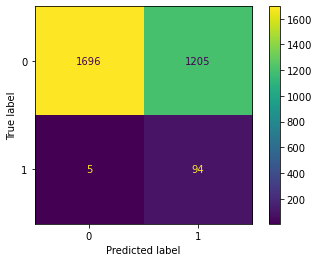

In [34]:
#Getting the confusion matrix array
cm = confusion_matrix(y_test_clean, y_hat_baseline_logreg)

#plotting the display matrix using scikit learns display matrix
ConfusionMatrixDisplay(cm).plot()
plt.show()

* The confusion matrix shows that the model correctly identified 94 failure cases, while only missing 5 (false negatives), reinforcing its high recall.  
* It however incorrectly classified 1205 non-failure instances as failures, indicating a large number of false positives.  

This confirms that while the model is effective at capturing failures, it  over-predicts the failure class, leading to many unnecessary maintenance alerts.

*Interpretation*  
The logistic regression baseline prioritises recall at the expense of precision, correctly identifying nearly all true machine failures. This aligns with the core business goal of avoiding unplanned downtime, however, it generates an unacceptably high volume of false alarms. In an operational setting, this would erode trust in the model and waste resources. 
The poor precision and low F1‑score indicate that the model is currently very aggressive in predicting the failure class

**Baseline Decision Tree Clasiffier**

In [31]:
# using the scikit-learn metric package to calculate the evaluation metrics
print("Accuracy:", accuracy_score(y_test_clean, y_hat_baseline_clf))
print("Precision:", precision_score(y_test_clean, y_hat_baseline_clf))
print("Recall:", recall_score(y_test_clean, y_hat_baseline_clf))
print("F1 Score:", f1_score(y_test_clean, y_hat_baseline_clf))

Accuracy: 0.9676666666666667
Precision: 0.5066666666666667
Recall: 0.7676767676767676
F1 Score: 0.6104417670682731


Observations:
* The Decision Tree model achieves a very high accuracy of about 96.8%, indicating that it correctly classifies the vast majority of instances, suggesting strong overall performance.  
* The model shows a moderate precision (50.7%), meaning that only about half of the predicted failure cases are actually true failures.  
* A 76.8% recall  indicates that the model successfully detects most failure cases, reflecting a trade-off of fewer false alarms but slightly more missed failures.
* The 0.61 F1 score is reflective of the balance between precision and recall, suggesting better practical use.

Similarly, taking a look at the Confusion Matrix for better understanding

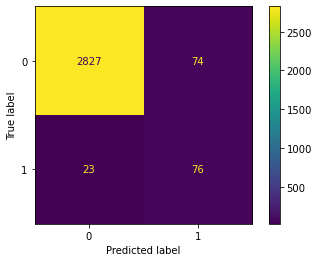

In [36]:
#Getting the confusion matrix array
cm = confusion_matrix(y_test_clean, y_hat_baseline_clf)

#plotting the display matrix
ConfusionMatrixDisplay(cm).plot()
plt.show()

* The model correctly caught 76 failures, missing a substantial 23 (about 30%), reinforcing relatively high recall but with a caveat.
* Most of the non failures were correctly predicted, flagging 75 as predicted failures, which is still quite high.

This provides something of a balance, but reinforces that there is tradeoff between false negative and false positive prediction.

*Interpretation*
